In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../data/db/bluestock_mf.db")

nav = pd.read_sql("SELECT * FROM fact_nav", engine)
fund_master = pd.read_sql("SELECT * FROM dim_fund", engine)
aum = pd.read_sql("SELECT * FROM fact_aum", engine)
sip = pd.read_sql("SELECT * FROM fact_sip_industry", engine)
transactions = pd.read_sql("SELECT * FROM fact_transactions", engine)
folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nav["nav_date"] = pd.to_datetime(nav["nav_date"])

print("NAV rows:", len(nav))
print("Fund master rows:", len(fund_master))


NAV rows: 46000
Fund master rows: 40


In [2]:
fig = px.line(
    nav.sort_values(["amfi_code", "nav_date"]),
    x="nav_date",
    y="nav",
    color="amfi_code",
    title="NAV Trend — All 40 Schemes (2022–2026)"
)
fig.update_layout(showlegend=False, height=600)
fig.show()

In [ ]:
pip install -U kaleido 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


KeyboardInterrupt: 

In [5]:
import os
os.makedirs("../reports/charts", exist_ok=True)

In [6]:
fig.write_image("../reports/charts/01_nav_trend_all_funds.png")

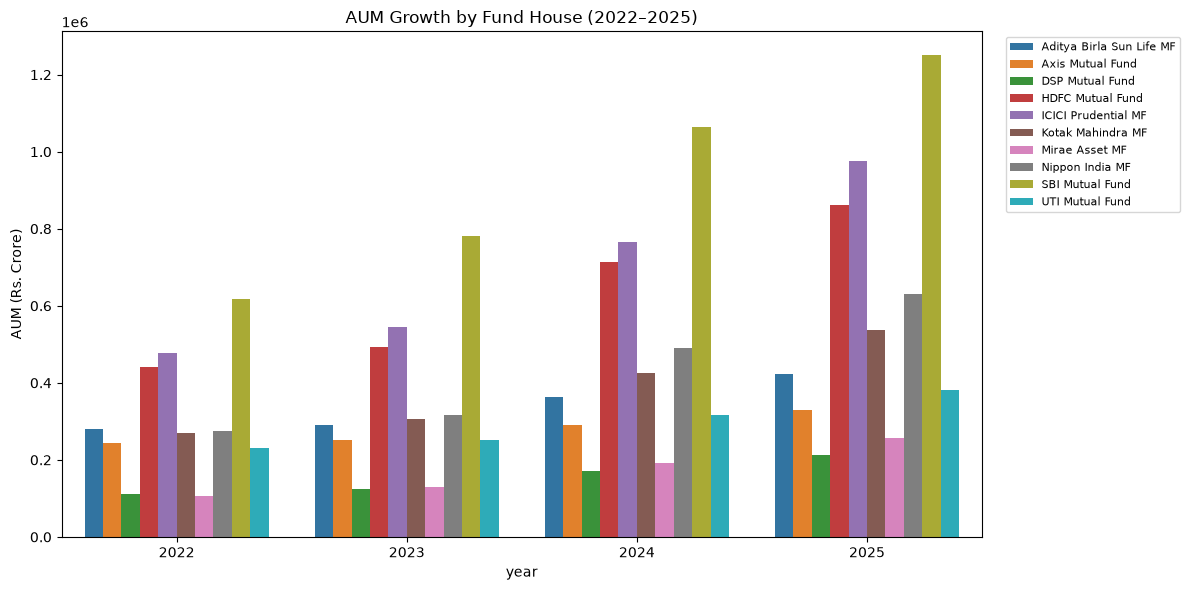

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

aum_yearly = aum.groupby(["year", "fund_house"])["aum_crore"].mean().reset_index()

sns.barplot(data=aum_yearly, x="year", y="aum_crore", hue="fund_house", ax=ax)
ax.set_title("AUM Growth by Fund House (2022–2025)")
ax.set_ylabel("AUM (Rs. Crore)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/charts/02_aum_growth_by_house.png", dpi=200)
plt.show()

In [9]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip.sort_values("month"),
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow (Jan 2022 – Dec 2025)"
)

peak_date = sip["month"].max()
peak_value = sip["sip_inflow_crore"].max()

fig.add_annotation(
    x=peak_date.strftime("%Y-%m-%d"),
    y=peak_value,
    text="₹31,002 Cr — All-Time High (Dec 2025)",
    showarrow=True,
    arrowhead=2,
    ax=-80,
    ay=-40
)

fig.update_layout(height=500)
fig.show()
fig.write_image("../reports/charts/03_sip_inflow_trend.png")

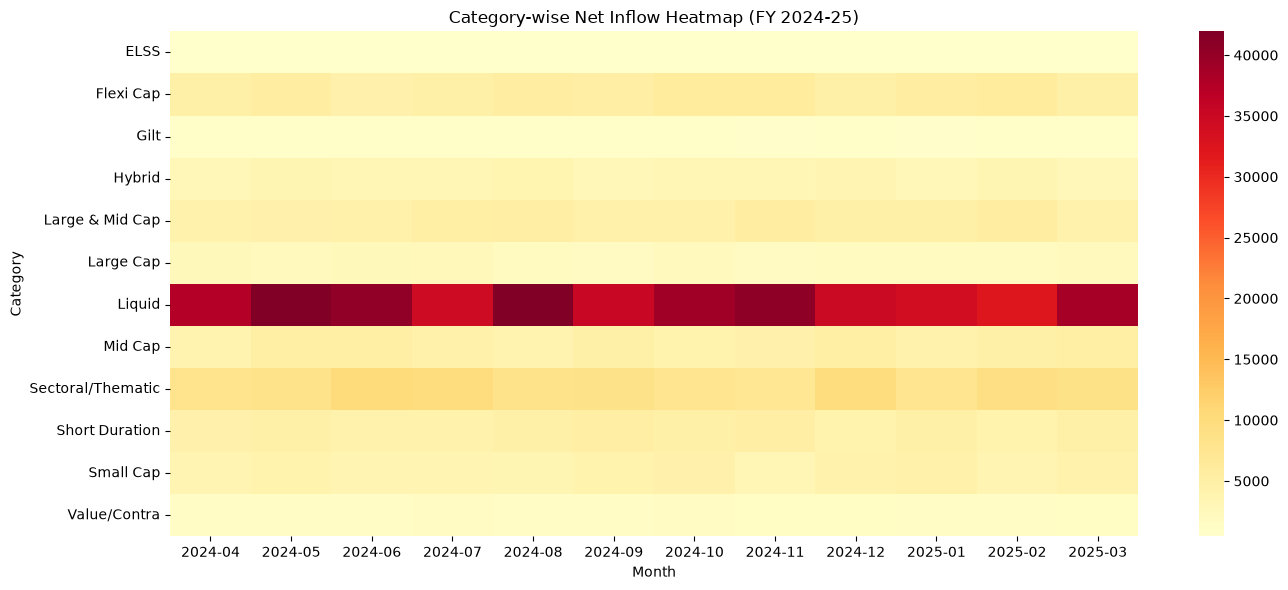

In [10]:
category_inflows = pd.read_csv("../data/raw/05_category_inflows.csv")

heatmap_data = category_inflows.pivot(index="category", columns="month", values="net_inflow_crore")

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, ax=ax)
ax.set_title("Category-wise Net Inflow Heatmap (FY 2024-25)")
ax.set_xlabel("Month")
ax.set_ylabel("Category")
plt.tight_layout()
plt.savefig("../reports/charts/04_category_inflow_heatmap.png", dpi=200)
plt.show()

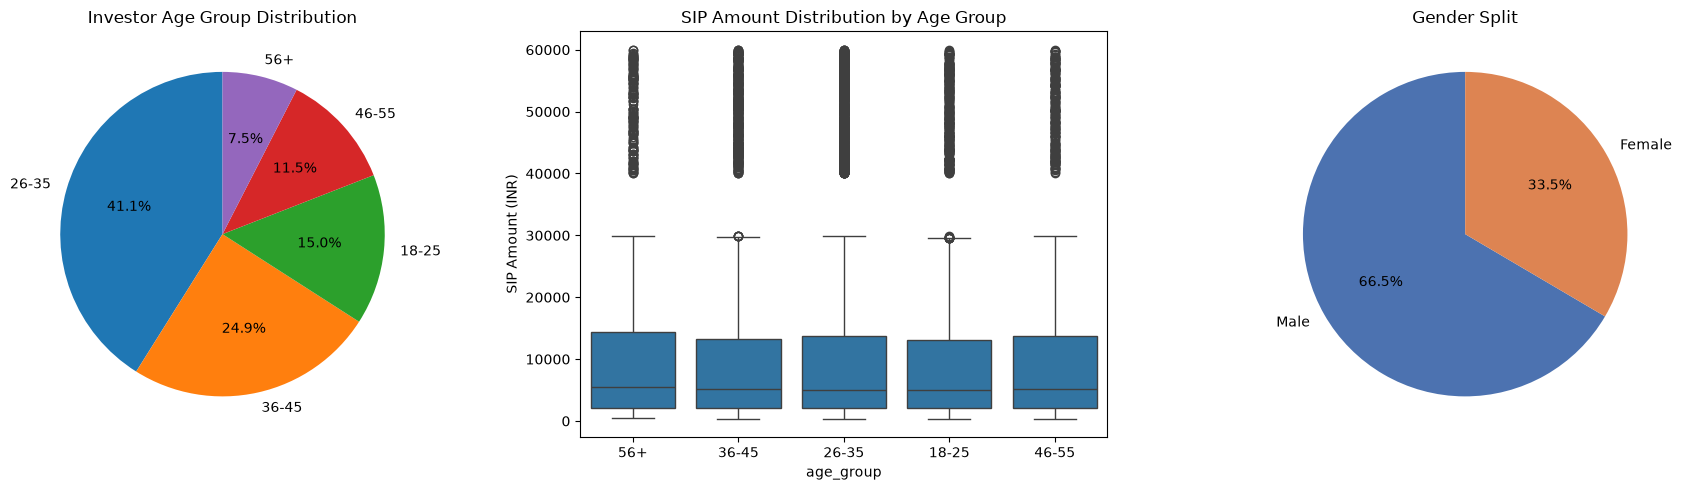

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Age group distribution pie chart
age_counts = transactions["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Investor Age Group Distribution")

# 2. SIP amount box plot by age group
sip_only = transactions[transactions["transaction_type"] == "Sip"]
sns.boxplot(data=sip_only, x="age_group", y="amount_inr", ax=axes[1])
axes[1].set_title("SIP Amount Distribution by Age Group")
axes[1].set_ylabel("SIP Amount (INR)")

# 3. Gender split
gender_counts = transactions["gender"].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90, colors=["#4C72B0", "#DD8452"])
axes[2].set_title("Gender Split")

plt.tight_layout()
plt.savefig("../reports/charts/05_investor_demographics.png", dpi=200)
plt.show()

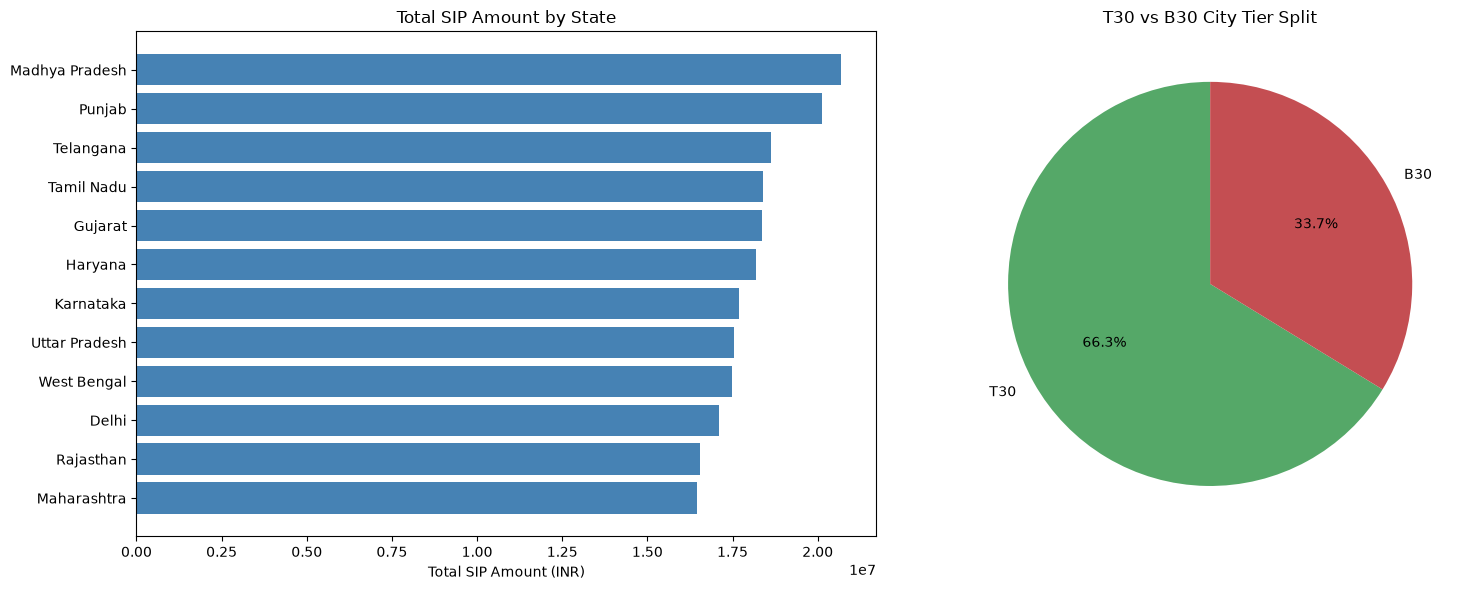

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar chart — SIP amount by state
state_sip = transactions[transactions["transaction_type"] == "Sip"].groupby("state")["amount_inr"].sum().sort_values()
axes[0].barh(state_sip.index, state_sip.values, color="steelblue")
axes[0].set_title("Total SIP Amount by State")
axes[0].set_xlabel("Total SIP Amount (INR)")

# T30 vs B30 pie chart
tier_counts = transactions["city_tier"].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%", startangle=90, colors=["#55A868", "#C44E52"])
axes[1].set_title("T30 vs B30 City Tier Split")

plt.tight_layout()
plt.savefig("../reports/charts/06_geographic_distribution.png", dpi=200)
plt.show()

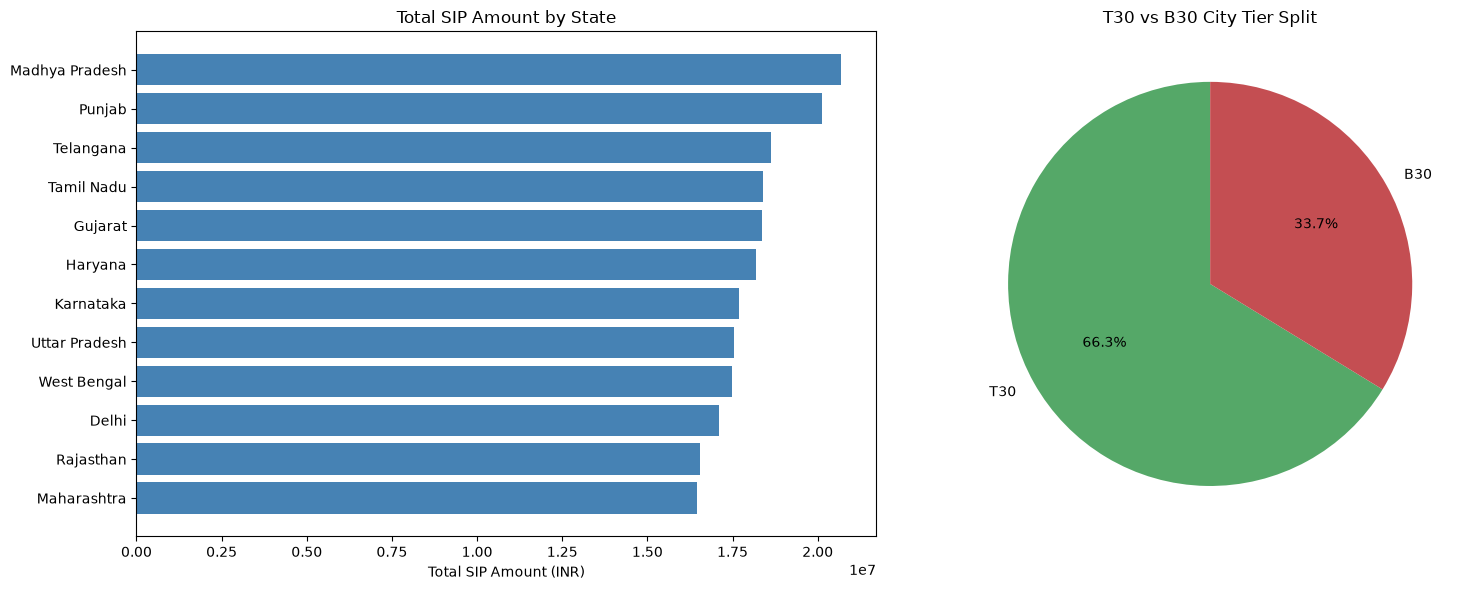

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar chart — SIP amount by state
state_sip = transactions[transactions["transaction_type"] == "Sip"].groupby("state")["amount_inr"].sum().sort_values()
axes[0].barh(state_sip.index, state_sip.values, color="steelblue")
axes[0].set_title("Total SIP Amount by State")
axes[0].set_xlabel("Total SIP Amount (INR)")

# T30 vs B30 pie chart
tier_counts = transactions["city_tier"].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%", startangle=90, colors=["#55A868", "#C44E52"])
axes[1].set_title("T30 vs B30 City Tier Split")

plt.tight_layout()
plt.savefig("../reports/charts/06_geographic_distribution.png", dpi=200)
plt.show()

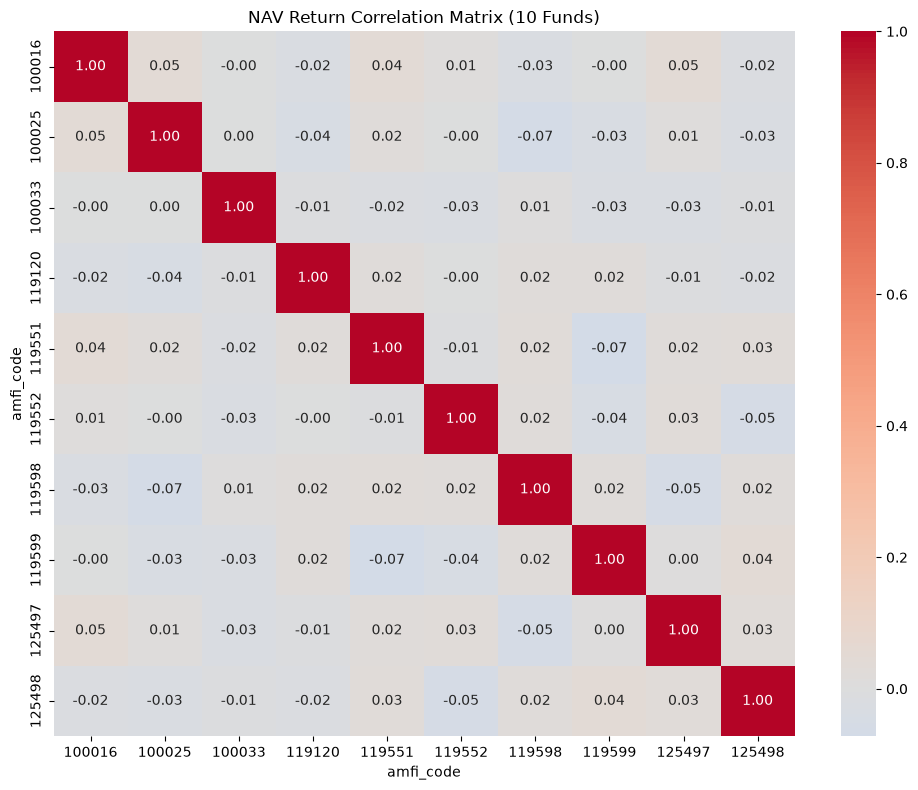

In [18]:
# Pick 10 funds and pivot NAV into wide format, then compute daily returns
top10_codes = fund_master["amfi_code"].head(10).tolist()
nav_subset = nav[nav["amfi_code"].isin(top10_codes)]

nav_wide = nav_subset.pivot(index="nav_date", columns="amfi_code", values="nav")
returns_wide = nav_wide.pct_change().dropna()

corr_matrix = returns_wide.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("NAV Return Correlation Matrix (10 Funds)")
plt.tight_layout()
plt.savefig("../reports/charts/08_correlation_matrix.png", dpi=200)
plt.show()

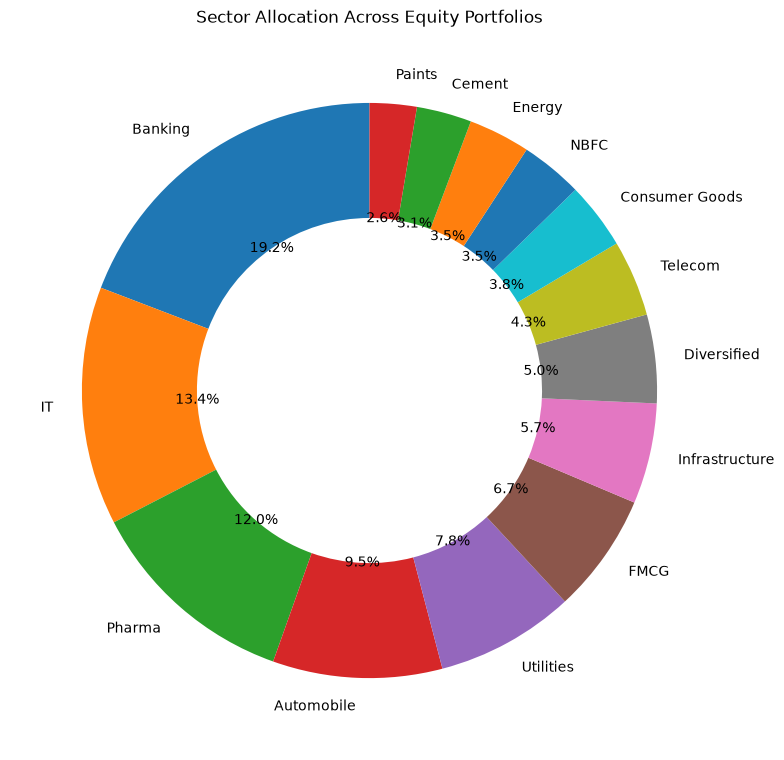

In [19]:
sector_weights = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sector_weights, labels=sector_weights.index, autopct="%1.1f%%", startangle=90,
       wedgeprops=dict(width=0.4))
ax.set_title("Sector Allocation Across Equity Portfolios")
plt.tight_layout()
plt.savefig("../reports/charts/09_sector_allocation.png", dpi=200)
plt.show()

## Key EDA Findings

1. **NAV levels are not comparable across funds** — different launch NAVs mean raw NAV trends must be viewed via normalized returns, not absolute values (see Chart 1).
2. **SBI Mutual Fund dominates AUM** — consistently the largest fund house across 2022–2025, reaching ~₹1.25L Cr by 2025, matching real-world AMFI data (Chart 2).
3. **SIP inflows show sustained, near-linear growth**, peaking at ₹31,002 Cr in Dec 2025 — reflecting deepening retail participation (Chart 3).
4. **[Fill in]** — describe a pattern you saw in the category heatmap (Chart 4).
5. **[Fill in]** — describe the dominant age group or SIP amount pattern (Chart 5).
6. **[Fill in]** — describe which state(s) lead in SIP amount, and T30 vs B30 split (Chart 6).
7. **Folio count nearly doubled**, growing from 13.26 Cr to 26.12 Cr between 2022–2025 (Chart 7).
8. **[Fill in]** — note which fund pairs show high/low correlation, and why that matters for diversification (Chart 8).
9. **[Fill in]** — describe which sector(s) dominate equity portfolio holdings (Chart 9).
10. **[Fill in]** — any anomaly or unexpected result you noticed anywhere in this notebook.